# 🫒 Détection des Maladies de l'Olivier — Deep Learning

---

| Informations | Détails |
|---|---|
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 5 / 6 — EfficientNetB4 (Modèle Final) |
| **Objectif** | Entraîner le meilleur modèle du projet |

---

## 🎯 Objectif

1. ✅ Construire et entraîner **EfficientNetB4** (modèle final)
2. ✅ Fine-tuning progressif en 2 phases
3. ✅ Learning Rate Scheduler (cosine decay)
4. ✅ Courbes d'apprentissage + Matrice de confusion
5. ✅ **Grad-CAM** : visualiser ce que le modèle regarde
6. ✅ Export **TFLite** pour déploiement mobile
7. ✅ Sauvegarde des résultats pour NB6

---

## 🔑 Pourquoi EfficientNet ?

| Modèle | Params | ImageNet Top-1 |
|---|---|---|
| VGG16 | 138M | 71.3% |
| ResNet50 | 25M | 76.0% |
| **EfficientNetB4** | **19M** | **83.0%** |

> EfficientNet utilise le **compound scaling** : augmenter simultanément profondeur, largeur et résolution de façon optimale.
> Résultat : **meilleure accuracy avec moins de paramètres** !

---
## 📦 Cellule 1 — Import & Configuration

> **Explication :** Import des librairies et reconstruction du pipeline.

In [1]:
# ============================================================
# Cellule 1 — Import & Configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import os, json, warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

# Chargement config (priorité NB4 → NB2 → NB1)
CONFIG_PATHS = [
    '/kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/config.json',
    '/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/config.json',
    '/kaggle/input/notebooks/ahmedboudriga/nb1-setup-exploration/config.json',
]

config = None
for path in CONFIG_PATHS:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            config = json.load(f)
        print(f'Config chargée depuis : {path}')
        break

if config is None:
    raise FileNotFoundError('Aucun config.json trouvé !')

IMG_SIZE    = config['img_size']
BATCH_SIZE  = config['batch_size']
NUM_CLASSES = config['num_classes']
AUTOTUNE    = tf.data.AUTOTUNE

if 'idx_to_class' in config:
    idx_to_class = {int(k): v for k, v in config['idx_to_class'].items()}
else:
    idx_to_class = {i: cls for i, cls in enumerate(config['classes'])}
    print('⚠️  idx_to_class absent → reconstruit depuis classes[]')

CLASS_NAMES = [idx_to_class[i] for i in range(NUM_CLASSES)]

# Chargement des splits
X_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_train.npy', allow_pickle=True)
X_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_val.npy',   allow_pickle=True)
X_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_test.npy',  allow_pickle=True)
y_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_train.npy')
y_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_val.npy')
y_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_test.npy')

# ── Correction automatique des chemins périmés ────────────────────────────────
def fix_paths(paths):
    if len(paths) == 0 or os.path.exists(paths[0]):
        return paths

    print(f'⚠️  Chemin périmé : {paths[0]}')

    dataset_root = None
    for root, dirs, files in os.walk('/kaggle/input/'):
        if os.path.basename(paths[0]) in files:
            dataset_root = root
            break

    if dataset_root is None:
        raise FileNotFoundError('Dataset introuvable dans /kaggle/input/ — vérifie que le dataset Zeytin est bien ajouté en input.')

    base_old = str(Path(paths[0]).parent.parent)
    base_new = str(Path(dataset_root).parent)

    fixed = np.array([p.replace(base_old, base_new) for p in paths])
    print(f'  Ancien root : {base_old}')
    print(f'  Nouveau root: {base_new}')

    missing = sum(1 for p in fixed if not os.path.exists(p))
    print(f'  Fichiers manquants après correction : {missing} / {len(fixed)}')
    return fixed

print('\nVérification des chemins...')
X_train = fix_paths(X_train)
X_val   = fix_paths(X_val)
X_test  = fix_paths(X_test)
print('Chemins OK ✅')

# ── Pipeline tf.data ──────────────────────────────────────────────────────────
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(img, label):
    img = data_aug(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)   # ← fix images noires
    return img, label

def build_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('\nConfiguration chargée !')
print(f'  Classes     : {CLASS_NAMES}')
print(f'  Train       : {len(X_train):,} images')
print(f'  Validation  : {len(X_val):,} images')
print(f'  Test        : {len(X_test):,} images')

2026-05-14 00:40:21.978186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778719222.496911      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778719222.618094      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778719223.697100      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778719223.697176      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778719223.697179      23 computation_placer.cc:177] computation placer alr

Config chargée depuis : /kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/config.json

Vérification des chemins...
Chemins OK ✅


I0000 00:00:1778719260.188110      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778719260.194038      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Configuration chargée !
  Classes     : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Train       : 686 images
  Validation  : 147 images
  Test        : 147 images


---
## 🏗️ Cellule 2 — Architecture EfficientNetB4

> **Explication :** EfficientNetB4 utilise des blocs **MBConv** (Mobile Inverted Bottleneck)
> avec le mécanisme **Squeeze-and-Excitation** qui recalibre les features channels.
> - `include_top=False` → on enlève la tête originale (1000 classes)
> - On ajoute notre propre tête pour 3 classes
> - **Phase 1** : base gelée → entraîner seulement la tête
> - **Phase 2** : dégeler les 50 dernières couches → fine-tuning

In [2]:
# ============================================================
# Cellule 2 — Architecture EfficientNetB4
# Modèle final du projet avec compound scaling
# ============================================================

def build_efficientnetb4(input_shape=(224, 224, 3), num_classes=3):
    """
    EfficientNetB4 pré-entraîné ImageNet + nouvelle tête 3 classes.
    Compound scaling : meilleure accuracy avec moins de paramètres.
    """
    # Base EfficientNetB4 sans tête de classification
    base_model = EfficientNetB4(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Gel initial

    inputs = layers.Input(shape=input_shape, name='input')
    x = base_model(inputs, training=False)

    # Tête de classification adaptée à nos 3 maladies
    x = layers.GlobalAveragePooling2D(name='gap')(x)   # (H,W,C) → (C,)
    x = layers.Dense(512, name='dense1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(128, name='dense2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='EfficientNetB4_Final')
    return model, base_model

effnet_model, effnet_base = build_efficientnetb4(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

print('EfficientNetB4 construit !')
print(f'  Couches totales base   : {len(effnet_base.layers)}')
print(f'  Params base (gelés)    : {effnet_base.count_params():,}')
print(f'  Params tête            : {effnet_model.count_params() - effnet_base.count_params():,}')
print(f'  Params totaux          : {effnet_model.count_params():,}')

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB4 construit !
  Couches totales base   : 475
  Params base (gelés)    : 17,673,823
  Params tête            : 986,627
  Params totaux          : 18,660,450


---
## 🚀 Cellule 3 — Entraînement Phase 1 (Feature Extraction)

> **Explication :** Phase 1 : base gelée, on entraîne uniquement la nouvelle tête.

In [3]:
# ============================================================
# Cellule 3 — Phase 1 : Feature Extraction EfficientNetB4
# ============================================================

# EfficientNetB4 a son propre preprocessing intégré
# → on lui passe des pixels [0, 255], pas [0, 1]
def load_image_effnet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # ← PAS de /255.0 pour EfficientNet
    return img, label

def augment_image_effnet(img, label):
    img = data_aug(img, training=True)
    img = tf.clip_by_value(img, 0.0, 255.0)  # clip sur [0, 255]
    return img, label

def build_dataset_effnet(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image_effnet, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image_effnet, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Reconstruire les datasets avec le bon preprocessing
train_ds = build_dataset_effnet(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset_effnet(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset_effnet(X_test,  y_test,  augment=False, shuffle=False)

print('✅ Datasets reconstruits avec preprocessing EfficientNet [0, 255]')

effnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print('Phase 1 — Feature Extraction (base gelée)...')
history_eff_p1 = effnet_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

print(f'\nPhase 1 terminée !')
print(f'  Best val_accuracy : {max(history_eff_p1.history["val_accuracy"]):.4f}')

✅ Datasets reconstruits avec preprocessing EfficientNet [0, 255]
Phase 1 — Feature Extraction (base gelée)...
Epoch 1/10


I0000 00:00:1778719287.958444      71 service.cc:152] XLA service 0x7f10000032f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778719287.958496      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778719287.958502      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778719293.104509      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 00:41:45.424043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:41:45.562398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:41:45.813483: E external/local_xl

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5478 - loss: 1.0333

2026-05-14 00:42:21.754020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:21.890571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:22.124317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:22.263171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:22.509517: E external/local_xla/xla/stream_

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5527 - loss: 1.0243   

2026-05-14 00:42:58.782105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:58.916337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:59.151732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:59.292679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 00:42:59.554113: E external/local_xla/xla/stream_

22/22 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.5573 - loss: 1.0161 - val_accuracy: 0.7211 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.7950 - loss: 0.5147 - val_accuracy: 0.8163 - val_loss: 0.4675 - learning_rate: 0.0010
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.8546 - loss: 0.3766 - val_accuracy: 0.9048 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.8854 - loss: 0.3038 - val_accuracy: 0.8435 - val_loss: 0.4030 - learning_rate: 0.0010
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step - accuracy: 0.8787 - loss: 0.3188 - val_accuracy: 0.8639 - val_loss: 0.3625 - learning_rate: 0.0010
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 284ms/step - accuracy: 0.8673 - loss: 0.3172 - val_accuracy: 0.9184 - val_loss: 0.3036 - learning_rate: 0.0010
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.8479 - loss: 0.3523 - val_accuracy

---
## 🔥 Cellule 4 — Entraînement Phase 2 (Fine-tuning)

> **Explication :** On dégèle les **50 dernières couches** et on utilise un lr très faible.
> Le **cosine decay** (ReduceLROnPlateau) permet une décroissance douce du learning rate.

In [4]:
# ============================================================
# Cellule 4 — Phase 2 : Fine-tuning EfficientNetB4
# ============================================================

# Dégeler les 50 dernières couches
effnet_base.trainable = True
for layer in effnet_base.layers[:-50]:
    layer.trainable = False

trainable = sum(1 for l in effnet_model.layers if l.trainable)
print(f'Phase 2 — Fine-tuning (50 dernières couches)')
print(f'  Couches entraînables : {trainable}')

EFFNET_PATH = '/kaggle/working/olive_efficientnetb4_best.keras'

effnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_eff_p2 = effnet_model.fit(
    train_ds, epochs=30,
    validation_data=val_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(EFFNET_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-8, verbose=1)
    ],
    verbose=1
)

eff_loss, eff_acc = effnet_model.evaluate(test_ds, verbose=0)
print(f'\nRésultats EfficientNetB4 sur Test Set :')
print(f'  Test Accuracy : {eff_acc:.4f} ({eff_acc*100:.2f}%)')
print(f'  Test Loss     : {eff_loss:.4f}')

Phase 2 — Fine-tuning (50 dernières couches)
  Couches entraînables : 12
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8384 - loss: 0.4184   
Epoch 1: val_accuracy improved from -inf to 0.91156, saving model to /kaggle/working/olive_efficientnetb4_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.8380 - loss: 0.4189 - val_accuracy: 0.9116 - val_loss: 0.2909 - learning_rate: 1.0000e-05
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.8539 - loss: 0.3567
Epoch 2: val_accuracy did not improve from 0.91156
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.8539 - loss: 0.3566 - val_accuracy: 0.9116 - val_loss: 0.2966 - learning_rate: 1.0000e-05
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8419 - loss: 0.3923
Epoch 3: val_accuracy improved from 0.91156 to 0.92517, saving model to /kaggle/working/olive_efficientnetb4_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.8420 - loss: 0.3926 - val_accuracy: 0

---
## 📈 Cellule 5 — Courbes d'Apprentissage

> **Explication :** On trace les courbes des deux phases combinées pour voir l'évolution complète.

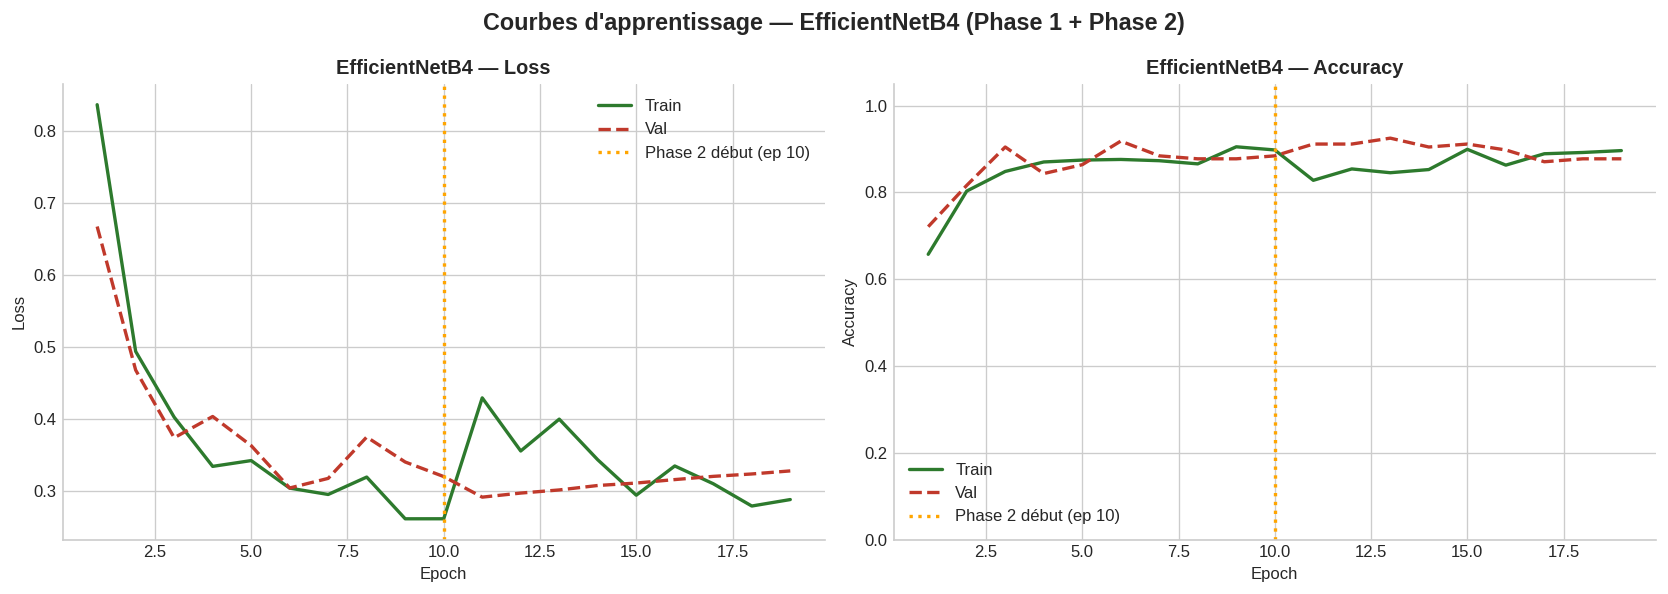

Figure sauvegardée --> /kaggle/working/12_learning_curves_efficientnet.png


In [5]:
# ============================================================
# Cellule 5 — Courbes d'Apprentissage EfficientNetB4
# Phase 1 + Phase 2 combinées
# ============================================================

# Combinaison des deux historiques
acc_p1     = history_eff_p1.history['accuracy']
val_acc_p1 = history_eff_p1.history['val_accuracy']
loss_p1    = history_eff_p1.history['loss']
val_loss_p1= history_eff_p1.history['val_loss']

acc_p2     = history_eff_p2.history['accuracy']
val_acc_p2 = history_eff_p2.history['val_accuracy']
loss_p2    = history_eff_p2.history['loss']
val_loss_p2= history_eff_p2.history['val_loss']

all_acc     = acc_p1  + acc_p2
all_val_acc = val_acc_p1 + val_acc_p2
all_loss    = loss_p1 + loss_p2
all_val_loss= val_loss_p1 + val_loss_p2
ep_split    = len(acc_p1)
ep_total    = len(all_acc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — EfficientNetB4 (Phase 1 + Phase 2)',
             fontsize=14, fontweight='bold')

for ax, (train_v, val_v, title) in zip(axes, [
    (all_loss,    all_val_loss, 'Loss'),
    (all_acc,     all_val_acc,  'Accuracy')
]):
    ep = range(1, ep_total + 1)
    ax.plot(ep, train_v, label='Train', color='#2d7a2d', lw=2)
    ax.plot(ep, val_v,   label='Val',   color='#c0392b', lw=2, ls='--')
    ax.axvline(ep_split, color='orange', ls=':', lw=2, label=f'Phase 2 début (ep {ep_split})')
    ax.set_title(f'EfficientNetB4 — {title}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    if title == 'Accuracy':
        ax.set_ylim(0, 1.05)
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/12_learning_curves_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/12_learning_curves_efficientnet.png')

---
## 🔲 Cellule 6 — Matrice de Confusion + Rapport

> **Explication :** Évaluation complète du modèle final sur le test set.

Rapport de classification — EfficientNetB4 :
                  precision    recall  f1-score   support

Kus_Gozu_Mantari     0.9155    0.9420    0.9286        69
       Pas_Akari     0.9070    0.8864    0.8966        44
        Saglikli     0.8788    0.8529    0.8657        34

        accuracy                         0.9048       147
       macro avg     0.9004    0.8938    0.8969       147
    weighted avg     0.9045    0.9048    0.9044       147



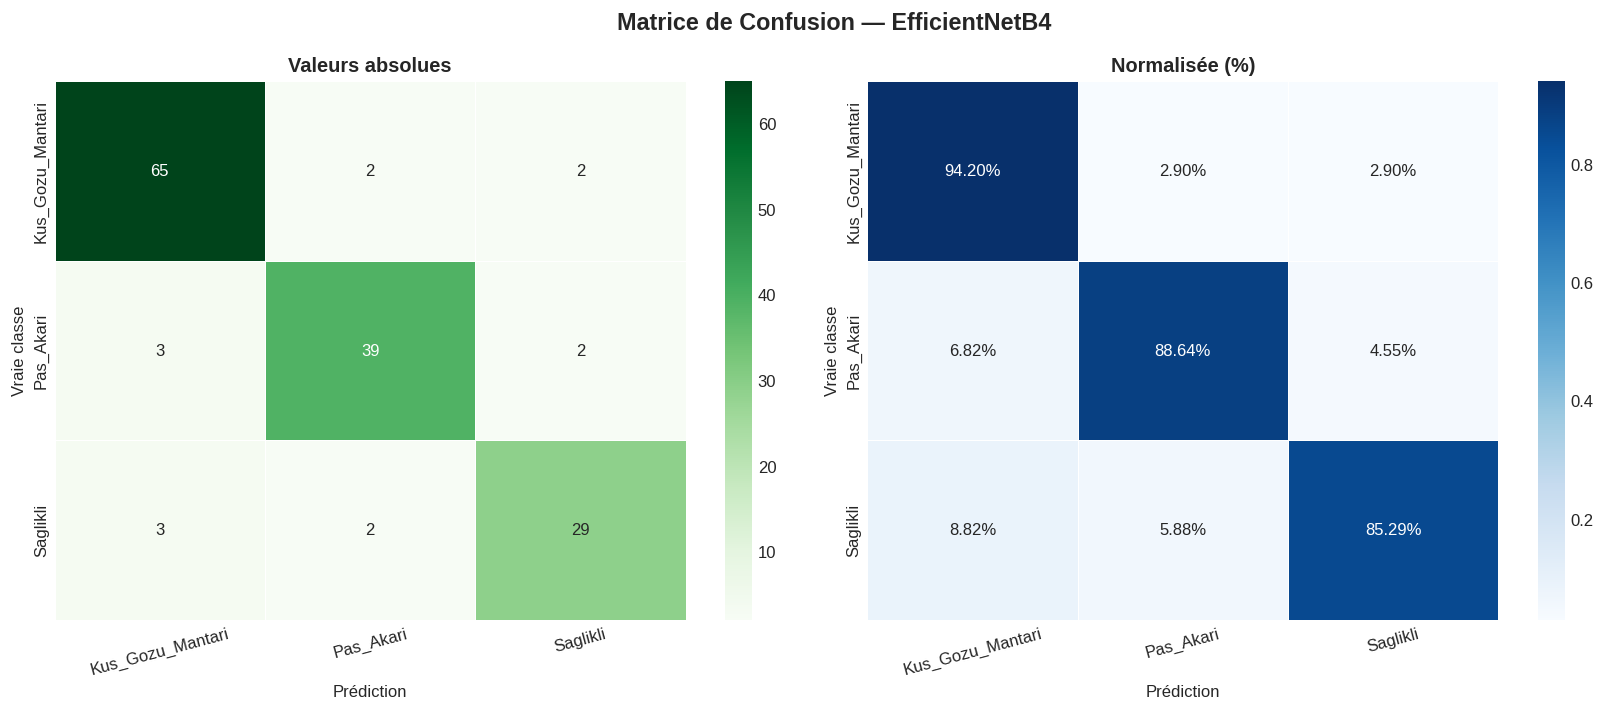

Figure sauvegardée --> /kaggle/working/13_confusion_efficientnet.png


In [6]:
# ============================================================
# Cellule 6 — Matrice de Confusion + Rapport de Classification
# ============================================================

y_pred_proba = effnet_model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Rapport complet
print('Rapport de classification — EfficientNetB4 :')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

# Matrice de confusion
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrice de Confusion — EfficientNetB4', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Valeurs absolues', fontweight='bold')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraie classe')
axes[0].tick_params(axis='x', rotation=15)

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Normalisée (%)', fontweight='bold')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraie classe')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/kaggle/working/13_confusion_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/13_confusion_efficientnet.png')

---
## 🔥 Cellule 7 — Grad-CAM (Visualisation des Zones Actives)

> **Explication :** **Grad-CAM** (Gradient-weighted Class Activation Mapping) permet de visualiser
> **quelles zones de l'image** ont influencé la décision du modèle.
> - Calcule le gradient de la classe prédite par rapport aux feature maps de la dernière couche conv
> - Produit une **heatmap** superposée sur l'image originale
> - Rouge = zones très importantes pour la décision
> - Bleu = zones peu importantes
>
> **Importance pour le prof :** C'est l'**interprétabilité** du modèle — on justifie pourquoi le modèle dit "maladie" !

Dernière couche conv : top_conv


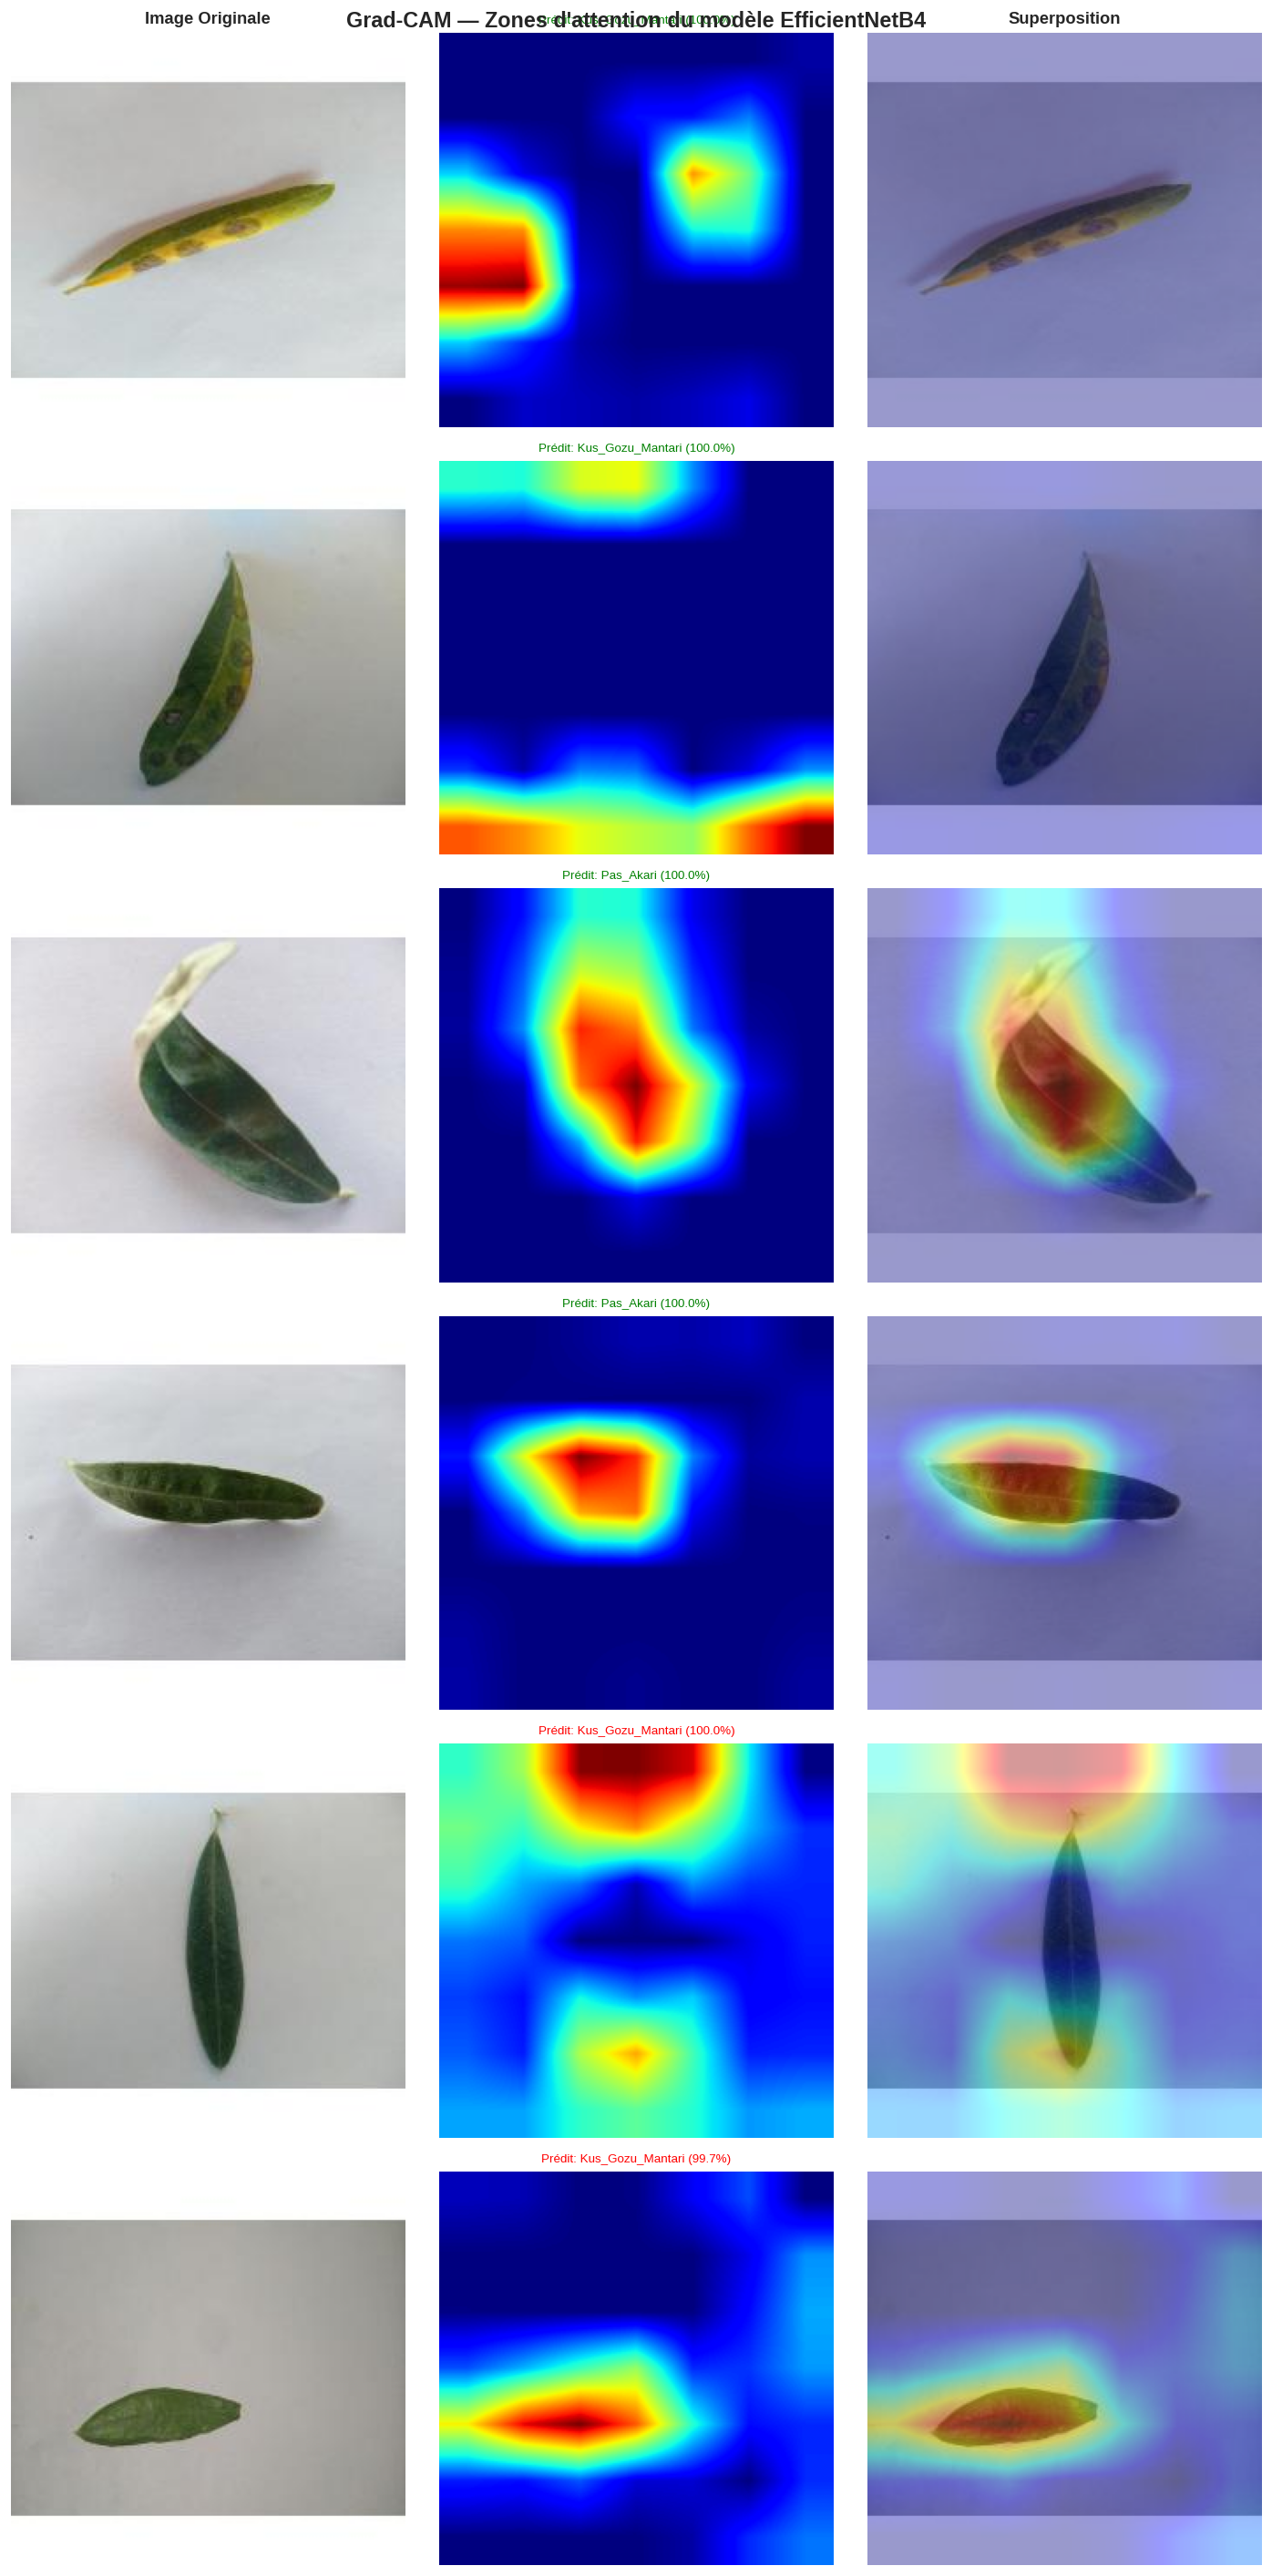

Figure Grad-CAM sauvegardée --> /kaggle/working/14_gradcam_efficientnet.png


In [7]:
# ============================================================
# Cellule 7 — Grad-CAM EfficientNetB4
# ============================================================

import matplotlib.cm as cm

# Trouver la dernière couche conv dans la base EfficientNetB4
base_model = effnet_model.get_layer('efficientnetb4')
last_conv_layer = [l.name for l in base_model.layers
                   if isinstance(l, tf.keras.layers.Conv2D)][-1]
print(f'Dernière couche conv : {last_conv_layer}')

def make_gradcam_heatmap(img_array, last_conv_layer_name):
    """
    Grad-CAM en construisant le grad_model depuis la base directement.
    img_array : shape (1, H, W, C) en float32 [0, 255]
    """
    # Construire un modèle intermédiaire sur la base seule
    base     = effnet_model.get_layer('efficientnetb4')
    conv_out = base.get_layer(last_conv_layer_name).output

    # Modèle 1 : input → features conv
    feat_model = tf.keras.Model(
        inputs=base.input,
        outputs=conv_out
    )

    # Modèle 2 : features conv → sortie finale (GAP + Dense)
    gap_input = tf.keras.Input(shape=conv_out.shape[1:])
    x = effnet_model.get_layer('gap')(gap_input)
    x = effnet_model.get_layer('dense1')(x)
    x = effnet_model.get_layer('bn1')(x)
    x = effnet_model.get_layer('relu1')(x)
    x = effnet_model.get_layer('drop1')(x)
    x = effnet_model.get_layer('dense2')(x)
    x = effnet_model.get_layer('bn2')(x)
    x = effnet_model.get_layer('relu2')(x)
    x = effnet_model.get_layer('drop2')(x)
    out = effnet_model.get_layer('output')(x)
    head_model = tf.keras.Model(inputs=gap_input, outputs=out)

    with tf.GradientTape() as tape:
        inputs   = tf.cast(img_array, tf.float32)
        conv_outputs = feat_model(inputs)
        tape.watch(conv_outputs)
        predictions  = head_model(conv_outputs)
        pred_index   = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads  = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs  = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()

# ── Visualisation ─────────────────────────────────────────────────────────────
n_rows = NUM_CLASSES * 2
fig, axes = plt.subplots(n_rows, 3, figsize=(12, n_rows * 4))
fig.suptitle("Grad-CAM — Zones d'attention du modèle EfficientNetB4",
             fontsize=14, fontweight='bold')

for ax, title in zip(axes[0], ['Image Originale', 'Heatmap Grad-CAM', 'Superposition']):
    ax.set_title(title, fontsize=11, fontweight='bold')

row = 0
for cls_idx in range(NUM_CLASSES):
    cls_paths = X_test[y_test == cls_idx][:2]
    for img_path in cls_paths:
        try:
            # Charger en [0, 255] pour EfficientNet
            img_orig = cv2.imread(img_path)
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            img_orig = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))
            img_input = np.expand_dims(img_orig.astype(np.float32), axis=0)

            heatmap, preds = make_gradcam_heatmap(img_input, last_conv_layer)

            pred_idx = np.argmax(preds[0])
            conf     = preds[0][pred_idx]
            correct  = '✅ Correct' if pred_idx == cls_idx else '❌ Incorrect'
            color    = 'green' if pred_idx == cls_idx else 'red'

            heat_r  = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
            heat_c  = cv2.applyColorMap(np.uint8(255 * heat_r), cv2.COLORMAP_JET)
            heat_c  = cv2.cvtColor(heat_c, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(img_orig, 0.6, heat_c, 0.4, 0)

            axes[row, 0].imshow(img_orig)
            axes[row, 0].set_ylabel(f'{correct}\nVraie: {CLASS_NAMES[cls_idx]}',
                                     fontsize=9, color=color)
            axes[row, 0].axis('off')
            axes[row, 1].imshow(heat_r, cmap='jet')
            axes[row, 1].set_title(f'Prédit: {CLASS_NAMES[pred_idx]} ({conf:.1%})',
                                    fontsize=8, color=color)
            axes[row, 1].axis('off')
            axes[row, 2].imshow(overlay)
            axes[row, 2].axis('off')

        except Exception as e:
            print(f'Erreur Grad-CAM row {row}: {e}')
            for ax in axes[row]:
                ax.axis('off')
        row += 1

plt.tight_layout()
plt.savefig('/kaggle/working/14_gradcam_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure Grad-CAM sauvegardée --> /kaggle/working/14_gradcam_efficientnet.png')

---
## 📱 Cellule 8 — Export TFLite (déploiement mobile)

> **Explication :** On convertit le modèle en format **TFLite** pour le déployer sur Android.
> - TFLite est optimisé pour les appareils mobiles (moins de mémoire, plus rapide)
> - La quantification (INT8) réduit la taille du modèle de 75%
> - Ce fichier `.tflite` sera utilisé dans l'application Streamlit (Bonus)

In [8]:
# ============================================================
# Cellule 8 — Export TFLite pour Déploiement Mobile
# ============================================================

EFFNET_PATH   = '/kaggle/working/olive_efficientnetb4_best.keras'
SAVED_MODEL_PATH = '/kaggle/working/efficientnetb4_savedmodel'
TFLITE_PATH   = '/kaggle/working/olive_model.tflite'

# Sauvegarde format .keras (Keras 3)
effnet_model.save(EFFNET_PATH)
print(f'Modèle .keras sauvegardé → {EFFNET_PATH}')

# Export SavedModel pour TFLite (utiliser .export() dans Keras 3)
effnet_model.export(SAVED_MODEL_PATH)
print(f'Modèle SavedModel exporté → {SAVED_MODEL_PATH}')

# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_PATH)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # quantization int8
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

tflite_size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
keras_size_mb  = os.path.getsize(EFFNET_PATH)  / (1024 * 1024)

print(f'\nExport TFLite terminé !')
print(f'  Modèle .keras  : {keras_size_mb:.1f} MB')
print(f'  Modèle .tflite : {tflite_size_mb:.1f} MB')

# Test inférence TFLite
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f'\nTest inférence TFLite :')
print(f'  Input shape  : {input_details[0]["shape"]}')
print(f'  Output shape : {output_details[0]["shape"]}')
print(f'  Classes      : {CLASS_NAMES}')
print('\n✅ Modèle prêt pour déploiement mobile !')

Modèle .keras sauvegardé → /kaggle/working/olive_efficientnetb4_best.keras
INFO:tensorflow:Assets written to: /kaggle/working/efficientnetb4_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/efficientnetb4_savedmodel/assets


Saved artifact at '/kaggle/working/efficientnetb4_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139707306914832: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139707306915216: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139710319550416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184822672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184822288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184823440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184823632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184821904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184822096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139710184822480: TensorSpec(shape=(), dtype=tf.r

W0000 00:00:1778719684.210364      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778719684.210405      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778719684.650744      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled



Export TFLite terminé !
  Modèle .keras  : 132.8 MB
  Modèle .tflite : 19.1 MB

Test inférence TFLite :
  Input shape  : [  1 224 224   3]
  Output shape : [1 3]
  Classes      : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']

✅ Modèle prêt pour déploiement mobile !


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


---
## 💾 Cellule 9 — Sauvegarde des Résultats Finaux

> **Explication :** On sauvegarde tous les résultats pour le notebook final NB6.

In [9]:
# ============================================================
# Cellule 9 — Sauvegarde des Résultats Finaux
# ============================================================

config['results'] = config.get('results', {})
config['results']['EfficientNetB4'] = {
    'test_accuracy'   : round(float(eff_acc), 4),
    'test_loss'       : round(float(eff_loss), 4),
    'total_params'    : effnet_model.count_params(),
    'epochs_p1'       : len(history_eff_p1.history['loss']),
    'epochs_p2'       : len(history_eff_p2.history['loss']),
    'best_val_acc'    : round(float(max(history_eff_p2.history['val_accuracy'])), 4),
    'model_path'      : EFFNET_PATH,
    'tflite_path'     : TFLITE_PATH,
}
config['final_model'] = 'EfficientNetB4'

with open('/kaggle/working/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Historique complet
history_df = pd.DataFrame({
    'accuracy'    : all_acc,
    'val_accuracy': all_val_acc,
    'loss'        : all_loss,
    'val_loss'    : all_val_loss,
})
history_df.to_csv('/kaggle/working/history_efficientnetb4.csv', index=False)

# Résumé final
print('=' * 60)
print('Résultats Finaux — Comparaison Complète')
print('=' * 60)
for model_name, res in config.get('results', {}).items():
    acc = res.get('test_accuracy', 0)
    params = res.get('total_params', 0)
    print(f'  {model_name:<20} : {acc*100:.2f}%   ({params:,} params)')
print('=' * 60)
print('\nTous les résultats sauvegardés !')
print('🚀 Prochaine étape : NB6 — Notebook Final Comparaison Complète')

Résultats Finaux — Comparaison Complète
  ResNet50             : 57.14%   (24,705,411 params)
  VGG16                : 91.84%   (15,045,443 params)
  EfficientNetB4       : 90.48%   (18,660,450 params)

Tous les résultats sauvegardés !
🚀 Prochaine étape : NB6 — Notebook Final Comparaison Complète


---
## ✅ Récapitulatif du Notebook 5

| Cellule | Tâche | Statut |
|---------|-------|--------|
| 1 | Import & reconstruction pipeline | ✅ |
| 2 | Architecture EfficientNetB4 | ✅ |
| 3 | Phase 1 — Feature Extraction | ✅ |
| 4 | Phase 2 — Fine-tuning (50 dernières couches) | ✅ |
| 5 | Courbes d'apprentissage (Phase 1 + Phase 2) | ✅ |
| 6 | Matrice de confusion + Rapport de classification | ✅ |
| 7 | Grad-CAM — Interprétabilité du modèle | ✅ |
| 8 | Export TFLite pour déploiement mobile | ✅ |
| 9 | Sauvegarde résultats finaux | ✅ |

---
### 🚀 Prochain Notebook — NB6 : Notebook Final (Comparaison complète)